## Import Packages

In [43]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score                                                         
from pathlib import Path
from joblib import load
import cartopy.crs as ccrs                                                                   
import cartopy.feature as cfeature  
import datetime

## Import Datasets

In [2]:
base_dir = Path('/gws/nopw/j04/wiser_ewsa/mrakotomanga/EPS/Data/Senegal/64x64/full/timesteps/32x32/lt1')

test_data_X = pd.read_csv(base_dir / 'test-senegal-input-t0-for-lt1.csv')
test_data_y_t1 = np.load(base_dir /  'test-senegal-output-at-lt1-resized.npy')
test_data_y_t0 = np.load(base_dir / 'test-senegal-output-t0-for-lt1-resized.npy')

In [3]:
train_data_X = pd.read_csv(base_dir / 'train-senegal-input-t0-for-lt1.csv')
train_data_y_t1 = np.load(base_dir / 'train-senegal-output-at-lt1-resized.npy')

### Preprocessing

Log transforming

In [4]:
train_data_X, val_data_X, train_y_lt1, val_y_lt1 = train_test_split(train_data_X, train_data_y_t1, test_size=0.3, random_state=12)

In [5]:
# Define all time suffixes
suffixes = ['', '_30', '_60', '_90', '_120']

# Define variable prefixes
prefixes = ['size', 'wp', 'd']
indices = ['1', '2', '3']

# Construct full column names
cols_to_log = [f'{prefix}{i}{suf}' for suf in suffixes for prefix in prefixes for i in indices]

# Apply log1p transform to each dataframe
for col in cols_to_log:
    train_data_X[col] = np.log1p(train_data_X[col].astype(float))
    test_data_X[col] = np.log1p(test_data_X[col].astype(float))
    val_data_X[col] = np.log1p(val_data_X[col].astype(float))

### Scaling

In [6]:
# Exclude all columns that start with 'mask'
mask_cols = [col for col in train_data_X.columns if col.startswith('mask')]

# Final list of features to scale
cols_to_scale = [col for col in train_data_X.columns if col not in mask_cols]

# Initialise scaler
scaler = load('/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/model/senegal/lead-time-1h/multi-time-steps-lt1.bin')

# Apply scaling
X_train_scaled = train_data_X.copy()
X_train_scaled[cols_to_scale] = scaler.transform(train_data_X[cols_to_scale])

X_val_scaled = val_data_X.copy()
X_val_scaled[cols_to_scale] = scaler.transform(val_data_X[cols_to_scale])

X_test_scaled = test_data_X.copy()
X_test_scaled[cols_to_scale] = scaler.transform(test_data_X[cols_to_scale])


In [7]:
# from joblib import dump
# dump(scaler, "./multi-time-steps-lt1.bin", compress=True)

In [8]:
assert X_train_scaled.shape[1] == 5 * 23, "Expected 115 features for 5 time steps of 23 features each."

In [9]:
# Reshape for LSTM: (samples, time_steps=5, features=23)
x_train = X_train_scaled.values.reshape(len(X_train_scaled), 5, 23)
x_val = X_val_scaled.values.reshape(len(X_val_scaled), 5, 23)
x_test = X_test_scaled.values.reshape(len(X_test_scaled), 5, 23)

# Targets
y_train = train_y_lt1
y_val = val_y_lt1
y_test = test_data_y_t1

In [10]:
model = tf.keras.models.load_model(
    '/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/model/senegal/lead-time-1h/multi-time-steps-lt1.keras', custom_objects=None, compile=True, safe_mode=True
)

In [11]:
pred_y_train = model.predict(x_train).flatten()
pred_y_test = model.predict(x_test).flatten()

1078/1078 [==============================] - 5s 5ms/step


In [12]:
def reliability_curve(y_true, y_pred, bin_size=0.1, min_predictions_per_bin=50):
    """
    Computes the reliability curve (calibration curve) for a binary classifier.
    
    Parameters:
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred (array-like): Predicted probabilities (between 0 and 1).
        bin_size (float): Width of the bins to divide probability space.
        min_predictions_per_bin (int): Minimum number of predictions in a bin to be included.
        
    Returns:
        bin_centers (list): Midpoints of the bins used.
        bin_positive_rates (list): Observed frequency of positive class in each bin.
        bin_counts (list): Number of predictions in each bin.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0, 1 + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    bin_positive_rates = []
    bin_centers_output = []
    bin_counts = []

    for lower, upper, center in zip(bins[:-1], bins[1:], bin_centers):
        in_bin = (y_pred >= lower) & (y_pred < upper)
        count_in_bin = np.sum(in_bin)
        
        if count_in_bin >= min_predictions_per_bin:
            observed_rate = np.mean(y_true[in_bin])
            bin_positive_rates.append(round(observed_rate, 3))
            bin_centers_output.append(round(center, 3))
            bin_counts.append(count_in_bin)

    return bin_centers_output, bin_positive_rates, bin_counts


def plot_roc(name, y_true, y_pred_proba, **kwargs):
    """
    Plots the ROC curve with hit rate vs false alarm rate (% scale).
    
    Parameters:
        name (str): Label for the curve (e.g., model name).
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities (from model).
        **kwargs: Additional plotting keyword arguments (e.g. linestyle, color).
    """
    fpr, tpr, _ = metrics.roc_curve(y_true, y_pred_proba)
    
    plt.plot(100 * fpr, 100 * tpr, label=name, linewidth=1.5, **kwargs)
    plt.xlabel('False Alarm Rate [%]')
    plt.ylabel('Hit Rate [%]')
    plt.xlim([-1, 100])
    plt.ylim([0, 105])
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')

In [13]:
auc_train = roc_auc_score(y_train.flatten(), pred_y_train)
auc_test = roc_auc_score(y_test.flatten(), pred_y_test)

In [18]:
auc_pers = roc_auc_score(y_test.flatten(), test_data_y_t0.flatten())

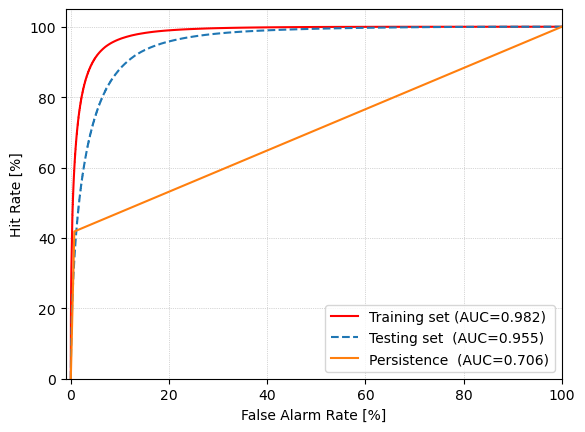

In [20]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train.flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test.flatten(), pred_y_test.flatten(), linestyle='--')
plot_roc(f"Persistence  (AUC={auc_pers:.3f})", y_test.flatten(), test_data_y_t0.flatten(), linestyle='-')
plt.legend(loc='lower right');

### Reliability diagram

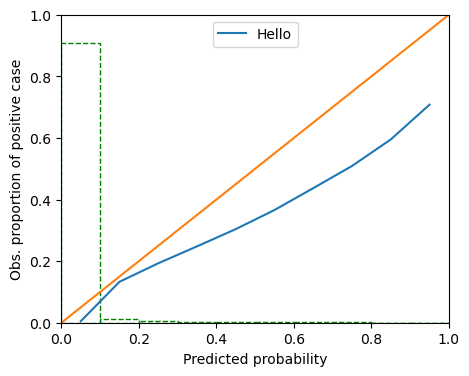

In [15]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.flatten(), pred_y_test.flatten())

plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label='Hello')

plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [21]:
from scipy.ndimage import uniform_filter

def compute_fss(observation, prediction, threshold=0.15, neighborhood_size=3):
    obs_binary = (observation >= threshold).astype(float)
    pred_binary = (prediction >= threshold).astype(float)

    obs_fraction = uniform_filter(obs_binary, size=neighborhood_size, mode='constant')
    pred_fraction = uniform_filter(pred_binary, size=neighborhood_size, mode='constant')

    mse = np.mean((obs_fraction - pred_fraction) ** 2)
    mse_ref = np.mean(obs_fraction ** 2 + pred_fraction ** 2)

    fss = 1 - mse / mse_ref
    return fss

In [25]:
observation = y_test
prediction = pred_y_test.reshape(y_test.shape)

In [36]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
neighborhood_sizes = [5, 7, 9]

for t in thresholds:
    fss_values = []
    for n in neighborhood_sizes:
        fss = compute_fss(observation, prediction, threshold=t, neighborhood_size=n)
        fss_values.append(fss)

<Figure size 800x600 with 0 Axes>

In [38]:
print(fss_values)

[0.1284968399445373, 0.13774538504481948, 0.14112830531770326]


In [65]:
index_display = 20000

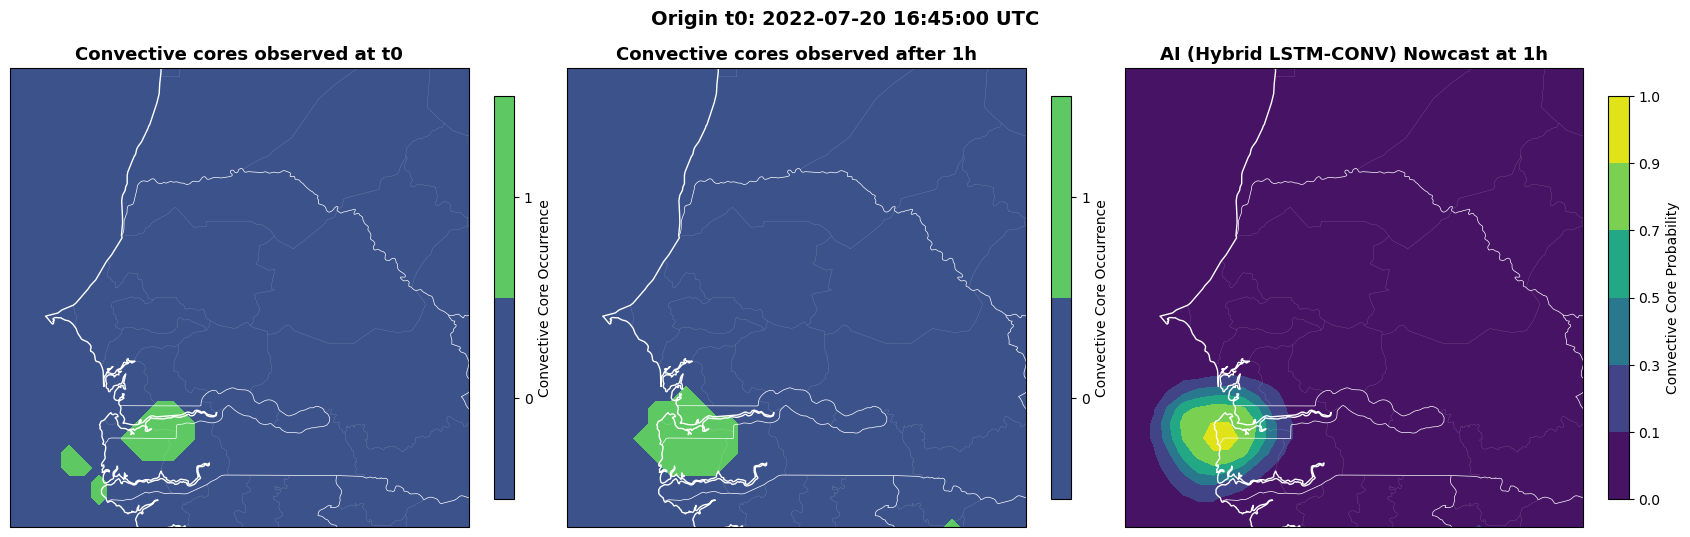

In [86]:
index_display = 20000

extent = (-18, -12, 12, 18)

# Parameters
CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX = 12, 18
CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX = -18, -12

extent = (CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX, CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX)
n_rows, n_cols = 32, 32  # Number of latitude points and longitude points

# Create linearly spaced values for latitudes and longitudes and create meshgrids
latitudes = np.linspace(CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX, n_rows)
longitudes = np.linspace(CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX, n_cols)
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

# Index for data to display
to_display = [
    test_data_y_t0[index_display],  # Add new data here
    y_test[index_display],
    pred_y_test.reshape(len(y_test), n_rows, n_cols)[index_display],
]
titles = ["Convective cores observed at t0", "Convective cores observed after 1h", "AI (Hybrid LSTM-CONV) Nowcast at 1h"]

colormaps = ["viridis", "viridis", "viridis"]  # Add colormap for the new subplot

# Create three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(17, 6), subplot_kw={'projection': ccrs.PlateCarree()})
# Loop through the axes to plot each subplot
for i, ax in enumerate(axes):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, edgecolor='white')
    ax.add_feature(cfeature.LAND, edgecolor='white')
    ax.tick_params(bottom=True, left=True, top=False, right=False)

    admin_1_borders = cfeature.NaturalEarthFeature(
      category='cultural',
      name='admin_1_states_provinces_lines',
      scale='10m',
      facecolor='none')

    ax.add_feature(admin_1_borders, edgecolor='white', linewidth=0.07)

    # Plot data with appropriate colormap
    if i == 0 or i == 1:  # True Binary target
        contour = ax.contourf(
            lon_grid, lat_grid, to_display[i], transform=ccrs.PlateCarree(), cmap=colormaps[i], levels=[-0.5, 0.5, 1.5]
        )
        # Add discrete colorbar
        cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.04, pad=0.05, ticks=[0, 1])
        cbar.set_label("Convective Core Occurrence")
        cbar.ax.set_yticklabels(["0", "1"])

    else:  # Continuous or additional data target
        contour = ax.contourf(
            lon_grid, lat_grid, to_display[i], transform=ccrs.PlateCarree(), cmap=colormaps[i], vmax=1, levels=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
        )
        # Add continuous colorbar
        cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.04, pad=0.05, ticks=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
                           )
        cbar.set_label("Probability" if i == 1 else "Convective Core Probability")

    ax.set_title(titles[i], fontsize=13, fontweight='bold')

# Adjust layout and display
plt.tight_layout()


data_display = test_data_X.iloc[index_display]
year = int(data_display["year_120"])
month = int(data_display["month_120"])
day = int(data_display["day_120"])
hour = int(data_display["hour_120"])
minute = int(data_display["minute_120"])


# Create a datetime object
nowcast_origin = datetime.datetime(year, month, day, hour, minute)
plt.suptitle(f"Origin t0: {nowcast_origin} UTC", fontsize=14, fontweight='bold')
plt.show()

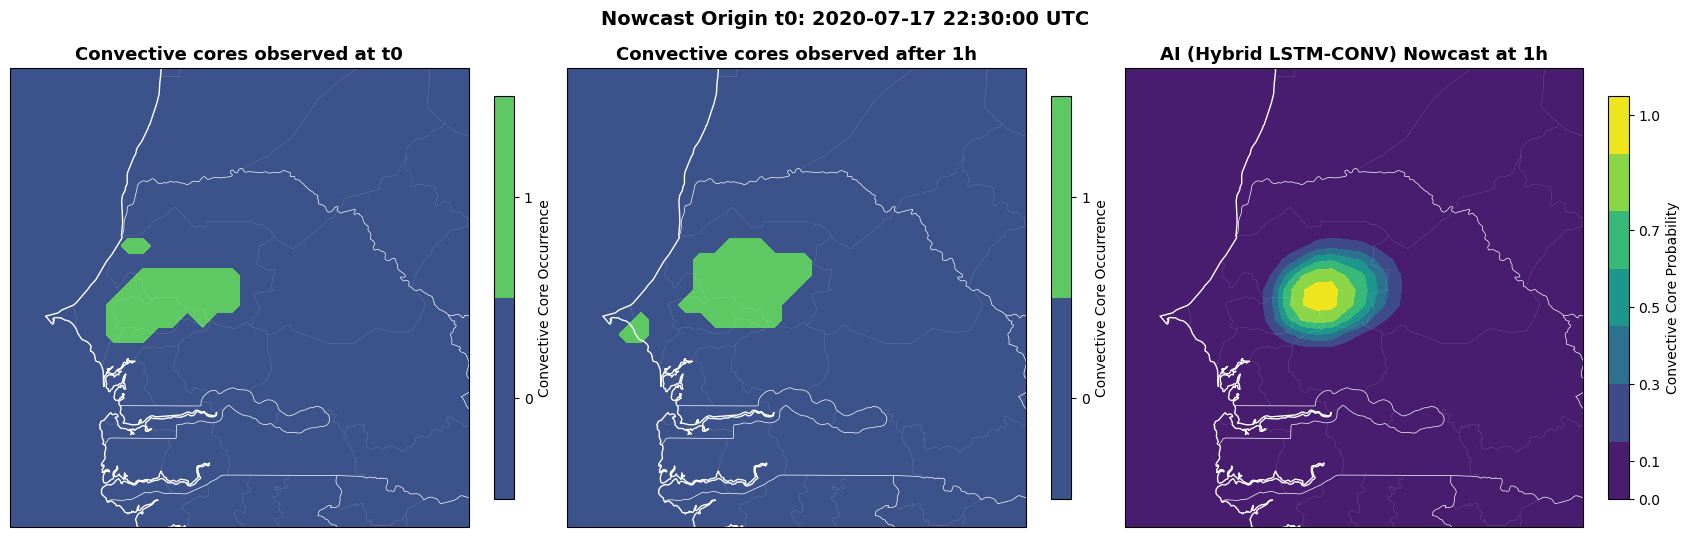

In [75]:
index_display = 3000

extent = (-18, -12, 12, 18)

# Parameters
CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX = 12, 18
CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX = -18, -12

extent = (CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX, CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX)
n_rows, n_cols = 32, 32  # Number of latitude points and longitude points

# Create linearly spaced values for latitudes and longitudes and create meshgrids
latitudes = np.linspace(CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX, n_rows)
longitudes = np.linspace(CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX, n_cols)
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

# Index for data to display
to_display = [
    test_data_y_t0[index_display],  # Add new data here
    y_test[index_display],
    pred_y_test.reshape(len(y_test), n_rows, n_cols)[index_display],
]
titles = ["Convective cores observed at t0", "Convective cores observed after 1h", "AI (Hybrid LSTM-CONV) Nowcast at 1h"]

colormaps = ["viridis", "viridis", "viridis"]  # Add colormap for the new subplot

# Create three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(17, 6), subplot_kw={'projection': ccrs.PlateCarree()})
# Loop through the axes to plot each subplot
for i, ax in enumerate(axes):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, edgecolor='white')
    ax.add_feature(cfeature.LAND, edgecolor='white')
    ax.tick_params(bottom=True, left=True, top=False, right=False)

    admin_1_borders = cfeature.NaturalEarthFeature(
      category='cultural',
      name='admin_1_states_provinces_lines',
      scale='10m',
      facecolor='none')

    ax.add_feature(admin_1_borders, edgecolor='white', linewidth=0.07)

    # Plot data with appropriate colormap
    if i == 0 or i == 1:  # True Binary target
        contour = ax.contourf(
            lon_grid, lat_grid, to_display[i], transform=ccrs.PlateCarree(), cmap=colormaps[i], levels=[-0.5, 0.5, 1.5]
        )
        # Add discrete colorbar
        cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.04, pad=0.05, ticks=[0, 1])
        cbar.set_label("Convective Core Occurrence")
        cbar.ax.set_yticklabels(["0", "1"])

    else:  # Continuous or additional data target
        contour = ax.contourf(
            lon_grid, lat_grid, to_display[i], transform=ccrs.PlateCarree(), cmap=colormaps[i], vmax=1
        )
        # Add continuous colorbar
        cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.04, pad=0.05, ticks=[0, 0.1, 0.3, 0.5, 0.7, 1])
        cbar.set_label("Probability" if i == 1 else "Convective Core Probability")

    ax.set_title(titles[i], fontsize=13, fontweight='bold')

# Adjust layout and display
plt.tight_layout()


data_display = test_data_X.iloc[index_display]
year = int(data_display["year_120"])
month = int(data_display["month_120"])
day = int(data_display["day_120"])
hour = int(data_display["hour_120"])
minute = int(data_display["minute_120"])


# Create a datetime object
nowcast_origin = datetime.datetime(year, month, day, hour, minute)
plt.suptitle(f"Nowcast Origin t0: {nowcast_origin} UTC", fontsize=14, fontweight='bold')
plt.show()